[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DVPombo/SOLETE/blob/main/examples/02_data_quality.ipynb)

# 02 — Data quality: the QC flag layer

SOLETE's real 15-month record has several documented data-quality issues (see
`KNOWN_ISSUES.md`) — round-number pressure sentinels, out-of-range humidity and wind
direction, an almost entirely unpopulated pair of solar-position columns, and a
substitution step that silently swaps in a model estimate for a chunk of the solar
power readings. `QC_SCHEMA.md` turns each of these into an explicit, queryable
`<column>_qc` column instead of leaving them as silent traps.

This notebook uses the same `SOLETE_sample.h5` as `01_dataset_overview.ipynb` — chosen
specifically (see `SAMPLE_DATA.md`) because it contains real examples of every one of
these issues, unlike the older `SOLETE_short.h5` quickstart file, which happens to have
zero flagged rows for four of the six flag types.

In [ ]:
# --- Colab / local setup -------------------------------------------------
# This cell makes the notebook runnable both from a local clone (the usual
# case) and from the "Open in Colab" badge above, where nothing but this
# .ipynb file exists yet in the Colab VM.
#
# 1. If `Functions.py` isn't found one directory up, we're not inside a local
#    clone of the repo (e.g. Colab) -- shallow-clone it once and move into
#    examples/, so the rest of this notebook (written assuming it runs from
#    examples/) works unmodified.
# 2. Either way, check whether the sample file this notebook needs is already
#    present before fetching it -- so re-running locally never re-downloads it.
import os
import subprocess
import urllib.request

ORG = "DVPombo"
REPO = "SOLETE"
BRANCH = "main"
SAMPLE_FILE = "SOLETE_sample.h5"
REPO_URL = "https://github.com/" + ORG + "/" + REPO + ".git"

if not os.path.exists("../Functions.py"):
    if not os.path.isdir(REPO):
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL],
            check=True,
        )
    os.chdir(REPO + "/examples")
    print("Cloned " + ORG + "/" + REPO + "@" + BRANCH + " and switched into examples/.")

# Check-before-fetch: the sample file may already be sitting in examples/
# (its real location in this repo) or one level up (where the loader calls
# below expect it) -- only hit the network if it's in neither place.
sample_here = os.path.exists(SAMPLE_FILE)
sample_up = os.path.exists("../" + SAMPLE_FILE)

if sample_here or sample_up:
    print(SAMPLE_FILE + " already present locally, skipping download.")
else:
    url = "https://raw.githubusercontent.com/" + ORG + "/" + REPO + "/" + BRANCH + "/examples/" + SAMPLE_FILE
    dest = "../" + SAMPLE_FILE
    print(SAMPLE_FILE + " not found locally, fetching from GitHub...")
    urllib.request.urlretrieve(url, dest)
    print("Done.")


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from Functions import import_SOLETE_sample, import_PV_WT_data

pd.set_option('display.max_columns', None)
%matplotlib inline

Control_Var = {'OriginalFeatures': [], 'PossibleFeatures': []}
PVinfo, WTinfo = import_PV_WT_data()
df = import_SOLETE_sample('../SOLETE_sample.h5', Control_Var, PVinfo, WTinfo)

I0000 00:00:1789171442.053345     332 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789171442.092795     332 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789171443.223297     332 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


SOLETE sample was imported from: ../SOLETE_sample.h5
    2160 rows, 2018-12-01 00:00:00 .. 2019-02-28 23:00:00

QC flags applied: {'Azimuth[deg]_qc': 2150, 'Elevation[deg]_qc': 2151, 'Pressure[mbar]_qc': 2147, 'HUMIDITY[%]_qc': 42, 'WIND_DIR[deg]_qc': 31} 

Expanding SOLETE with King's PV Performance Model
    Cleaning noise and curtailment from active power production
    QC flag (substitution): {'P_Solar[kW]_qc': 1272}
    Smoothing zeros

Adding new Types with codes: []

SOLETE has been successfully expanded from: 11 to: 22 features.




## The flag layer, briefly

Every `<column>_qc` column holds exactly one of these integer codes (mutually
exclusive — a cell is never "half missing, half implausible"; see `QC_SCHEMA.md` §2
for why bitmasks were considered and rejected):

| Value | Meaning |
|---|---|
| 0 | valid |
| 1 | missing |
| 2 | sensor_error *(reserved, not used by any rule yet)* |
| 3 | physically_implausible |
| 4 | interpolated *(reserved, not used by any rule yet)* |
| 5 | aggregation_affected_by_gaps *(reserved, not used by any rule yet)* |
| 6 | suspected_curtailment_or_model_substituted |

Six columns get one of these flags in this dataset, mapping to six findings in
`KNOWN_ISSUES.md`:

1. **`Pressure[mbar]`** → flag 3, wherever the value is one of the known round-number
   sentinels (`1000.0`, `2000.0`, `3000.0`) or outside the physically-plausible
   sea-level range (870–1085 mbar).
2. **`HUMIDITY[%]`** → flag 3, wherever the value is outside `[0, 1]` (it's stored as a
   fraction, not a percentage, despite the column name).
3. **`WIND_DIR[deg]`** → flag 3, wherever the value is `≥ 360°` or negative — not a
   valid compass bearing.
4. **`Azimuth[deg]`** and **`Elevation[deg]`** → flag 1 (missing), wherever the value is
   exactly `0.0` — these two columns are ~99.9% constant zero across the full 15-month
   file, with real values on exactly one calendar day.
5. **`P_Solar[kW]`** → flag 6, wherever the physics-model estimate (`Pac`) was ≥ 1.5×
   the raw measurement — the row's `P_Solar[kW]` value was then replaced by the model
   estimate as a noise/curtailment-cleaning step.

Let's look at real flagged rows for each one.

### 1. `Pressure[mbar]` — physically_implausible

In [2]:
pressure_flagged = df[df['Pressure[mbar]_qc'] == 3]
print(f"{len(pressure_flagged)} of {len(df)} rows flagged ({len(pressure_flagged)/len(df):.1%})")
pressure_flagged[['Pressure[mbar]', 'Pressure[mbar]_qc']].head()

2147 of 2160 rows flagged (99.4%)


,Pressure[mbar],Pressure[mbar]_qc
2018-12-01 00:00:00,2000.0,3
2018-12-01 01:00:00,1000.0,3
2018-12-01 02:00:00,1000.0,3
2018-12-01 03:00:00,1000.0,3
2018-12-01 04:00:00,1000.0,3


In [3]:
df['Pressure[mbar]'].value_counts().head(5)

Pressure[mbar]
1000.000000    2057
2000.000000      90
998.344811        1
997.532282        1
997.531353        1
Name: count, dtype: int64

### 2. `HUMIDITY[%]` — physically_implausible

In [4]:
humidity_flagged = df[df['HUMIDITY[%]_qc'] == 3]
print(f"{len(humidity_flagged)} of {len(df)} rows flagged ({len(humidity_flagged)/len(df):.1%})")
humidity_flagged[['HUMIDITY[%]', 'HUMIDITY[%]_qc']].head()

42 of 2160 rows flagged (1.9%)


,HUMIDITY[%],HUMIDITY[%]_qc
2018-12-03,1.905057,3
2018-12-07,1.982301,3
2018-12-08,1.800000,3
2018-12-09,1.600000,3
2018-12-11,1.600000,3


### 3. `WIND_DIR[deg]` — physically_implausible

In [5]:
winddir_flagged = df[df['WIND_DIR[deg]_qc'] == 3]
print(f"{len(winddir_flagged)} of {len(df)} rows flagged ({len(winddir_flagged)/len(df):.1%})")
winddir_flagged[['WIND_DIR[deg]', 'WIND_DIR[deg]_qc']].head()

31 of 2160 rows flagged (1.4%)


,WIND_DIR[deg],WIND_DIR[deg]_qc
2018-12-03,447.577938,3
2018-12-07,442.568769,3
2018-12-08,560.447749,3
2018-12-09,402.131981,3
2018-12-11,598.167824,3


### 4. `Azimuth[deg]` / `Elevation[deg]` — missing

In [6]:
azimuth_missing = df[df['Azimuth[deg]_qc'] == 1]
azimuth_real = df[df['Azimuth[deg]_qc'] == 0]
print(f"Azimuth[deg]: {len(azimuth_missing)} of {len(df)} rows flagged missing")
print(f"The only real (non-zero) values fall on: {sorted(azimuth_real.index.normalize().unique())}")
azimuth_real[['Azimuth[deg]', 'Elevation[deg]', 'Azimuth[deg]_qc', 'Elevation[deg]_qc']]

Azimuth[deg]: 2150 of 2160 rows flagged missing
The only real (non-zero) values fall on: [Timestamp('2019-01-16 00:00:00')]


,Azimuth[deg],Elevation[deg],Azimuth[deg]_qc,Elevation[deg]_qc
2019-01-16 07:00:00,-10.832542,0.000000,0,1
2019-01-16 08:00:00,-56.907645,0.404477,0,0
2019-01-16 09:00:00,-44.271533,4.864375,0,0
2019-01-16 10:00:00,-30.931550,9.370473,0,0
2019-01-16 11:00:00,-16.955775,12.129905,0,0
2019-01-16 12:00:00,-2.628165,12.875160,0,0
2019-01-16 13:00:00,11.634535,11.534902,0,0
2019-01-16 14:00:00,25.450450,8.237662,0,0
2019-01-16 15:00:00,38.590075,3.322427,0,0
2019-01-16 16:00:00,44.794950,0.023018,0,0


### 5. `P_Solar[kW]` — suspected_curtailment_or_model_substituted

In [7]:
substituted = df[df['P_Solar[kW]_qc'] == 6]
print(f"{len(substituted)} of {len(df)} rows flagged ({len(substituted)/len(df):.1%})")
substituted[['P_Solar[kW]', 'Pac', 'P_Solar_model_substituted', 'P_Solar[kW]_qc']].head()

1272 of 2160 rows flagged (58.9%)


,P_Solar[kW],Pac,P_Solar_model_substituted,P_Solar[kW]_qc
2018-12-01 00:00:00,0.0,0.0,True,6
2018-12-01 01:00:00,0.0,0.0,True,6
2018-12-01 02:00:00,0.0,0.0,True,6
2018-12-01 03:00:00,0.0,0.0,True,6
2018-12-01 04:00:00,0.0,0.0,True,6


## Seeing it: flagged vs. unflagged pressure over time

A table of counts is convincing enough on its own, but a plot makes it immediate: here's
`Pressure[mbar]` over the first three weeks of the sample, with flagged (implausible)
points picked out in red. The pattern — a value pinned to a suspiciously round number
for long stretches — is exactly what a real sensor doesn't do.

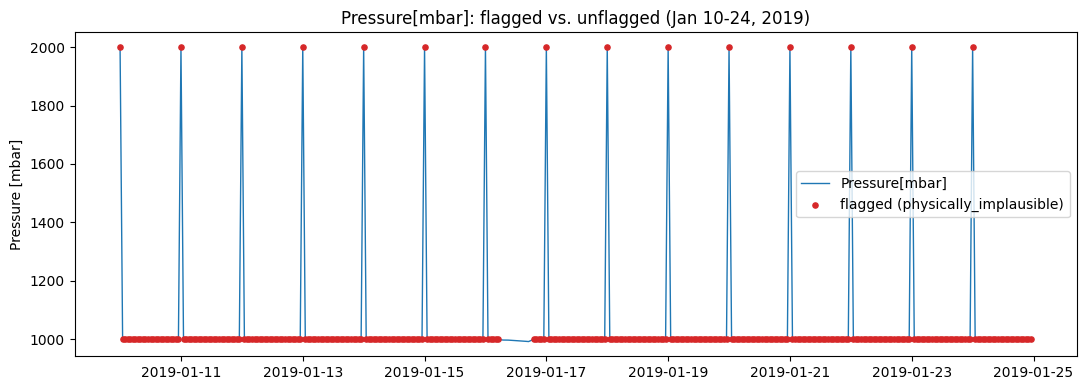

347 of 360 rows shown here are flagged.
Almost the entire sample is pinned to a sentinel value -- the brief dip to a
real-looking reading on Jan 16 is one of only 13 non-sentinel pressure rows
in the whole 2,160-row sample (see the value_counts() above).


In [8]:
window = df.loc['2019-01-10':'2019-01-24']
flagged_mask = window['Pressure[mbar]_qc'] == 3

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(window.index, window['Pressure[mbar]'], color='tab:blue', linewidth=1,
        label='Pressure[mbar]', zorder=1)
ax.scatter(window.index[flagged_mask], window.loc[flagged_mask, 'Pressure[mbar]'],
           color='tab:red', s=14, label='flagged (physically_implausible)', zorder=2)
ax.set_ylabel('Pressure [mbar]')
ax.set_title('Pressure[mbar]: flagged vs. unflagged (Jan 10-24, 2019)')
ax.legend()
fig.tight_layout()
plt.show()

print(f"{flagged_mask.sum()} of {len(window)} rows shown here are flagged.")
print("Almost the entire sample is pinned to a sentinel value -- the brief dip to a")
print("real-looking reading on Jan 16 is one of only 13 non-sentinel pressure rows")
print("in the whole 2,160-row sample (see the value_counts() above).")

## Why this matters

This isn't just a bookkeeping exercise. `Functions.py::Rincon_Pombo_ThermodynamicModel`
consumes `Pressure[mbar]` **directly** (`p = data['Pressure[mbar]'] * 100`, converted to
Pascals for a `CoolProp` humid-air calculation) to estimate PV module temperature. Without
this QC flag layer, that model would silently inherit the sentinel-value problem shown
above on the vast majority of rows — its temperature estimate would be quietly wrong
almost all the time, with no way to tell which rows to distrust. With the flag in place,
anyone using that model's output can filter or weight by `Pressure[mbar]_qc` instead of
finding out the hard way.